# T11 — A free surface: letting the rift subside, and two traps on the way

**Cluster D — Part 3, lithospheric deformation.** Requires the container.

T10 ended with a working rift and two derived limits on how long it stays
valid. This notebook removes one of them, reports honestly on the other, and
spends most of its length on the two mistakes made getting there — because both
are the kind that produce a model that runs, produces plausible numbers, and is
wrong.

The limit being removed is the flat lid. T10's mesh is Eulerian and fixed, both
walls are driven outward, the base is no-flux, so incompressibility forces
material *in* through the top at the full boundary velocity. That inflow is
fictitious — a real rift subsides — and it replaces the entire upper crust in
about a hundred steps.

With a free surface, the same extension produces a **rift basin**.

## Learning objectives

1. Add a free surface to a kinematically driven model, and explain why it forces you to add buoyancy too.
2. Non-dimensionalise a body force correctly, and know which pressure the yield criterion should see.
3. Recognise the failure signature of a time-integrated boundary condition coupled to an iterative solver.
4. Judge when a numerical capability is worth its installation cost, and what to do when it is not.

## Prerequisites and runtime

* T10. **Requires the container.**
* **Measured runtime: about 15 minutes.** Four model runs, two of them
  deliberately wrong.

In [1]:
# === USER CONFIGURATION ===
NX, NY = 64, 32
STEPS = 20
BUG_NX, BUG_NY = 48, 24     # the two wrong runs; coarse, the signal is large
HEATFLOW = 0.055
SEED_KM = 10.0

In [2]:
import json
import os
import subprocess
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "..")
from geodynkit import plotting

DRIVER = os.path.join("..", "tools", "gadopt_rift_case.py")


def run(tag, nx=NX, ny=NY, **kw):
    """Run the rift driver. Returns its RESULT dict."""
    cmd = [sys.executable, DRIVER, "--nx", str(nx), "--ny", str(ny),
           "--heatflow", str(HEATFLOW), "--seed-km", str(SEED_KM),
           "--out", f"{tag}.npz"]
    for k, v in kw.items():
        flag = f"--{k.replace('_', '-')}"
        cmd += [flag] if v is True else [flag, str(v)]
    p = subprocess.run(cmd, capture_output=True, text=True)
    for line in p.stdout.splitlines():
        if line.startswith("RESULT "):
            return json.loads(line[len("RESULT "):])
    raise RuntimeError(f"no result:\n{p.stderr[-1500:]}")

## 1. Why a free surface drags buoyancy in with it

G-ADOPT's free surface adds one scalar unknown per free-surface boundary — the
surface displacement $\eta$ — to the mixed space alongside velocity and
pressure, and solves

$$\frac{\partial \eta}{\partial t} = \mathbf{u}\cdot\mathbf{n}
  \qquad\text{with a surface load}\qquad \sigma_{nn} = \rho g \eta$$

together with Stokes. Explicitly coupling a free surface to a Stokes solve —
advance $\eta$, then solve, then advance again — is notoriously unstable at any
timestep you would want to use, which is why $\eta$ lives *inside* the mixed
system rather than beside it.

Look at the load. It is $\rho g \eta$: **topography only pushes back because
rock has weight.** T10's model has no buoyancy at all — it is driven purely
kinematically and the layered density does nothing — so a free surface bolted
onto it would have nothing to restore it. Adding the surface means adding the
body force.

### Getting the scaling right

The equations are non-dimensionalised by the Spiegelman convention: lengths by
the domain depth $H$, velocities by the boundary velocity $U_0$, stress by
$\mu_0 U_0 / H$. A dimensional body force $\rho g$ therefore enters as

$$\mathrm{B} = \frac{g H^2}{\mu_0 U_0} \approx 0.124 \ \text{per kg m}^{-3}$$

so a mantle density of 3300 gives a non-dimensional body force of about 409.
That number is worth a sanity check in dimensional terms: a kilometre of
topography weighs $\rho g h \approx 26$ MPa, against a driving stress
$\mu_0 U_0 / H \approx 8$ MPa. **A few hundred metres of relief is already
comparable to the force driving the whole experiment**, which is the real reason
the flat lid was not a harmless simplification.

## 2. Trap one: which pressure does the yield criterion see?

Drucker–Prager needs the *total* pressure:

$$\sigma_y = C\cos\phi + P\sin\phi$$

With no body force, the pressure the solver returns is purely dynamic and
carries no lithostatic part, so T10 supplies it analytically —
$P = \rho_{\text{layered}}\, g z + p$.

Switch buoyancy on and that stops being true. With the body force written as
$-(\rho - \rho_{\text{ref}}) g$, the returned $p$ now contains everything except
the *reference* lithostatic pressure $\rho_{\text{ref}} g z$, which the
reference state absorbs. Keep the analytic layered term as well and you count
the lithostatic pressure roughly twice.

Here is that run. Nothing about it looks broken from the outside.

In [3]:
good_bug = run("fs_ok_short", nx=BUG_NX, ny=BUG_NY, steps=10, free_surface=True)
lith_bug = run("fs_lith", nx=BUG_NX, ny=BUG_NY, steps=10, free_surface=True,
               fs_bug="lithostatic")
for name, r in (("correct", good_bug), ("double lithostatic", lith_bug)):
    print(f"{name:>20}: peak strain {r['strain_max_initial']:.3f} -> "
          f"{r['strain_max_final']:.3f}   "
          f"topography {r['topography_km'][0]:+.2f} to {r['topography_km'][1]:+.2f} km")

             correct: peak strain 1.512 -> 1.698   topography -4.05 to -1.20 km
  double lithostatic: peak strain 1.493 -> 1.650   topography -3.92 to -1.22 km


**Look how small the signature is.** The topography is within a couple of
percent. The strain still grows past the seeded maximum, just slightly less far
— around 3% lower after ten steps. Nothing here would make you stop and look.

That is exactly what makes this class of error dangerous, and it is worth
contrasting with the next section: a bug in the *coupling* announces itself with
a factor of forty, while a bug in the *physics* whispers. The quiet one is the
one that reaches publication.

There is no clever detection trick to offer. The defence is structural: when you
add a term to the governing equations, ask what *else* was standing in for it.
The lithostatic pressure was being supplied analytically precisely because the
body force was absent, and adding the body force without removing the stand-in
is the kind of thing only bookkeeping catches.

(An earlier draft of this notebook claimed the double-count made peak strain
*decay*. It does not. That measurement was taken while the section 3 bug was
also present, and the decay belonged to that one. The correction is left visible
here because attributing a symptom to the wrong cause is itself the most common
way this sort of investigation goes wrong.)

## 3. Trap two: a boundary condition that integrates, inside an iteration

G-ADOPT's `StokesSolver.solve()` ends with

```python
self.solution_old.assign(self.solution)
```

which is exactly right when one solve is one timestep. Our visco-plastic model
cannot do that: it needs a Picard iteration, forty solves per timestep, because
Newton will not converge from a cold start (T09 section 3).

The free-surface equation is $(\eta - \eta_{\text{old}})/\Delta t =
\mathbf{u}\cdot\mathbf{n}$. So $\eta$ was being advanced **once per iteration**
instead of once per timestep.

In [4]:
time_bug = run("fs_timelevel", nx=BUG_NX, ny=BUG_NY, steps=5, free_surface=True,
               fs_bug="time-level")
ok_5 = run("fs_ok_5", nx=BUG_NX, ny=BUG_NY, steps=5, free_surface=True)
for name, r in (("correct", ok_5), ("advanced per iteration", time_bug)):
    lo, hi = r["topography_km"]
    print(f"{name:>24}: topography {lo:+9.3f} to {hi:+9.3f} km   "
          f"relief {hi - lo:7.3f} km")

                 correct: topography    -2.091 to    -0.578 km   relief   1.513 km
  advanced per iteration: topography   -63.950 to   -63.941 km   relief   0.009 km


Sixty-odd kilometres of subsidence in five steps, against two — and, tellingly,
**no relief at all**: the whole surface drops as a rigid sheet, because what is
being integrated is the iteration count rather than time.

The factor is the give-away. It is not a plausible-looking twenty percent; it is
the number of Picard iterations. Whenever a time-integrated quantity comes out
wrong by a suspiciously round factor, count how many times you called the thing
that integrates it.

The fix is to reset the solver's stored time level to the start-of-step state
before every Picard solve, so each iterate solves the *same* time-discrete
problem, and to advance it once when the step is accepted. Both solver objects
share the solution but each keeps its own `solution_old`, so both need it.

## 4. The rift basin

Now the comparison the notebook exists for: the same model, the same twenty
steps, with and without a deformable surface.

In [5]:
flat = run("rift_flat", steps=STEPS)
free = run("rift_free", steps=STEPS, free_surface=True)

print(f"{'':>14} {'peak strain':>12} {'in-seed':>9} {'outside':>9} {'psi excursion':>14}")
for name, r in (("flat lid", flat), ("free surface", free)):
    print(f"{name:>14} {r['strain_max_final']:>12.3f} {r['strain_in_seed']:>9.3f} "
          f"{r['strain_outside']:>9.3f} {r['level_set_excursion']:>14.5f}")
print(f"\ntopography, free surface: {free['topography_km'][0]:+.3f} to "
      f"{free['topography_km'][1]:+.3f} km")

                peak strain   in-seed   outside  psi excursion
      flat lid        2.109     1.197     0.052        0.00300
  free surface        2.050     1.172     0.052        0.00142

topography, free surface: -7.326 to -2.783 km


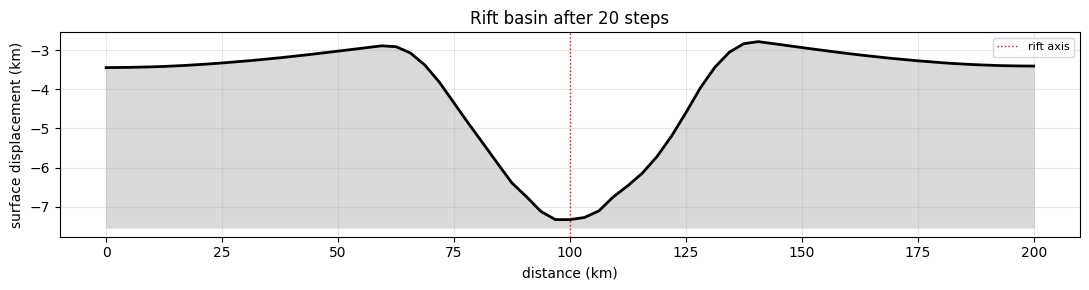

deepest -7.326 km at x = 100 km;  relief 4.543 km


In [6]:
d = np.load("rift_free.npz")
x, topo = d["x_km"], d["topography_km"]
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(x, topo, "k-", lw=2)
ax.fill_between(x, topo, topo.min() - 0.2, color="0.85")
ax.axvline(100, color="r", ls=":", lw=1, label="rift axis")
ax.set(xlabel="distance (km)", ylabel="surface displacement (km)",
       title="Rift basin after %d steps" % STEPS)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print(f"deepest {topo.min():+.3f} km at x = {x[int(np.argmin(topo))]:.0f} km;"
      f"  relief {topo.max() - topo.min():.3f} km")

A basin, deepest on the axis, flanks a kilometre or so higher. Slightly
asymmetric, because the seed is random and real rifts are asymmetric for the
same reason.

**Read the relief, not the absolute depth.** The mean subsidence here is several
kilometres over 1.6 Myr, which is an order of magnitude faster than any real
rift, and that is not a modelling failure so much as a consequence of what
$\eta$ is: the time-integral of the normal velocity at the top. The box must
shed material through its side walls at the rate the boundary condition
dictates, so the surface drops at roughly $U_0$ whatever isostasy would prefer.
The *difference* between axis and flank is the part the physics sets, and it is
the number to quote.

Note too that the strain fields are barely distinguishable between the two runs
over twenty steps. That is expected — a few kilometres of surface displacement
against a hundred kilometres of lithosphere is a small perturbation — and it is
a reminder that the free surface was added to make the *long* run meaningful,
not to change the short one. What does improve immediately is the level-set
excursion, which halves.

Check that the lid has actually stopped importing rock:

In [7]:
for name, f in (("flat lid", "rift_flat.npz"), ("free surface", "rift_free.npz")):
    dd = np.load(f)
    vz = dd["vz"][0]
    print(f"{name:>14}: vz on the top boundary  mean {vz.mean():+.4f}  "
          f"min {vz.min():+.4f}  max {vz.max():+.4f}")

      flat lid: vz on the top boundary  mean +0.9989  min +0.6298  max +2.4185
  free surface: vz on the top boundary  mean +0.9995  min +0.7166  max +1.5651


Both still show downward motion at the boundary of order the driving velocity,
and that is correct — but it now means two different things. Under the flat lid
it is material *entering the domain*, with no record kept. With a free surface
it is the surface *subsiding*, and $\eta$ is the record. The number is similar;
the physics is not.

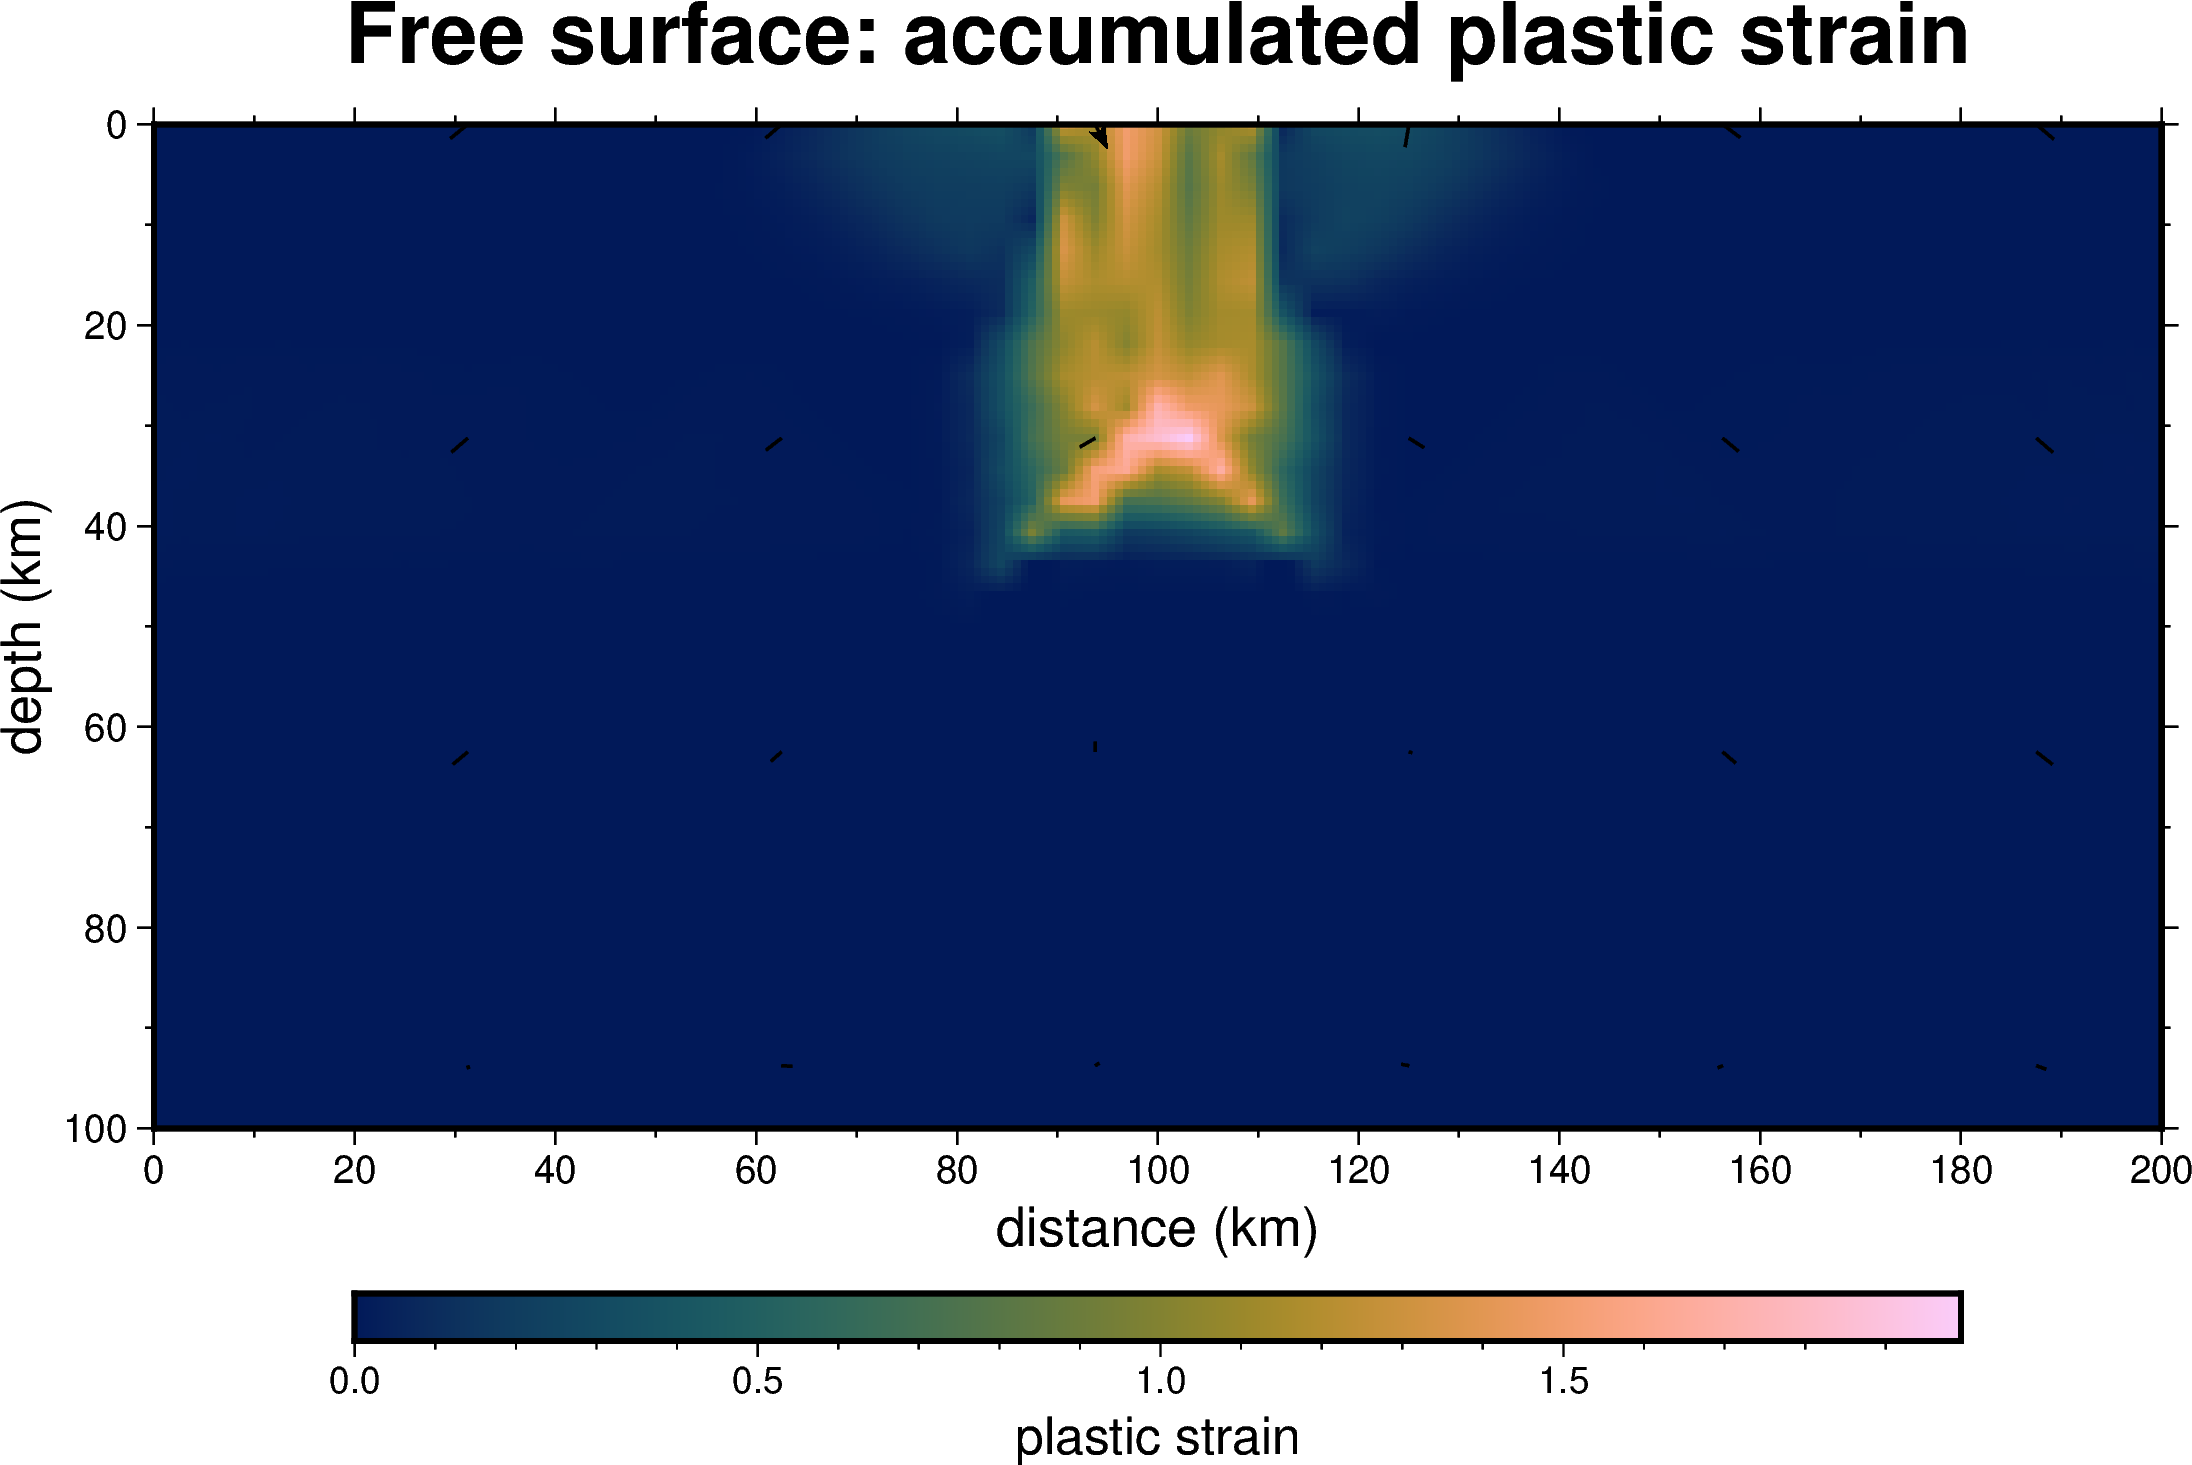

In [8]:
fig = plotting.field_panel(
    d["strain"], d["x_km"], d["depth_km"], kind="strain_rate",
    title="Free surface: accumulated plastic strain",
    label="plastic strain", vx=d["vx"], vz=d["vz"], every=40, width_cm=17.0,
)
fig.show()

## 5. The limit that is *not* fixed, and why

T10's other limit was the mesh: the run ends when the necking lower crust thins
to about 3.5 vertical cells, at which point the two conservative level sets
bounding it overlap and each one's reinitialisation corrupts the other. That one
is still there, and it is worth being precise about why.

**The textbook answer is metric-based adaptive refinement** — build a
`RiemannianMetric` from the solution, call `adapt`, get a mesh with cells
concentrated where the interfaces are. G-ADOPT ships a demo of exactly this.

**It is not available in this container**, for three independent reasons:

1. `adapt` drives the **Mmg** library through PETSc. The Firedrake image's PETSc
   is configured without `--download-mmg` or `--download-parmmg`; there are no
   MMG symbols in `petscconf.h`.
2. The `animate` package that provides `RiemannianMetric` is not installed.
3. Mmg adapts **simplex** meshes only. This suite uses quadrilaterals
   throughout, so enabling it would also mean changing the discretisation.

Fixing that means rebuilding PETSc and Firedrake from source, on both amd64 and
arm64, for one notebook — in a suite whose whole premise is that `docker run`
works. **That is a reasonable thing to decline**, and knowing when a capability
is not worth its installation cost is a real research skill rather than a
failure of nerve.

### The obvious substitute does not work either

We know in advance where the resolution is wanted — the rift nucleates at a seed
we placed — so a *statically graded* mesh should serve. It does not, and the
experiment is instructive twice over.

The first attempt used the obvious clustering map, $s \mapsto
\operatorname{sign}(s)|s|^p$. Its derivative vanishes at $s = 0$, so cells at
the axis collapse: at $p = 1.6$ the widest cell was **10.6×** the narrowest and
the level-set excursion after three steps was 0.0139 against 0.0002 on a uniform
mesh — seventy times worse, from a mesh meant to help.

Replacing it with a bounded-derivative map,
$s' = \operatorname{artanh}(s\tanh b)/b$, removed that pathology. But on the
real test at 96×48:

| | uniform | clustered towards axis and surface |
|---|---|---|
| aborts at step | **40** | **18** |
| seconds per step | 21 | 44 |
| cell height in the crust | 2.08 km | 1.55 km |

**Earlier failure, at twice the cost.** Finer cells where the necking happens
bought nothing.

One untested hypothesis, left as an exercise below: the reinitialisation
pseudo-timestep is a single global $0.5\min(\epsilon)$, which is a uniform-mesh
assumption. On a mesh with a 3× cell-size ratio the large cells are
under-reinitialised in proportion, and that would more than cancel the benefit.

A genuine bug did fall out of the attempt: `h_min` was hardcoded as
`aspect / nx`, which is the *average* cell width on a graded mesh, so the CFL
limiter was using a timestep several times too large for the smallest cells
while reporting a comfortable Courant number.

## 6. Where this leaves the model

| | T09 | T10 | T11 |
|---|---|---|---|
| visco-plastic rheology | yes | yes | yes |
| time-dependent, strain weakening | no | yes | yes |
| localises | no (seed-set) | yes | yes |
| evolving topography | no | no | **yes** |
| temperature evolves | no | no | no |
| resolves arbitrary necking | no | no | no |

Two things are still missing and both are honest gaps rather than oversights.
**Temperature is frozen**: the geotherm is prescribed and does not respond to
thinning, so the model cannot produce the thermal weakening a real rift depends
on — coupling `EnergySolver` is the obvious next rung. And the **necking limit**
stands, for the reasons in section 5.

What the suite gains from this notebook is a rift that subsides, and two
worked examples of a failure mode that no amount of care with the physics
protects you from: a model that runs, converges, and reports plausible numbers
while being wrong for a reason that lives in the coupling rather than in either
component.

## Extend this

* Test the reinitialisation hypothesis in section 5: scale the pseudo-timestep to the *local* interface thickness rather than the global minimum, and re-run the clustered case. Does it get past step 18?
* Run the free-surface case to 60 steps. Does the basin deepen linearly, or does the rift flank start to rebound?
* Set `--fs-bug lithostatic` and run 30 steps rather than 10. How long does it take before the difference is obvious from the strain field alone?
* Compare the axis-to-flank *relief* against a simple Airy isostatic estimate for the crustal thinning the model produces. Do they agree, and should they? Then do the same for the absolute depth, and explain the discrepancy.
* The free surface here is linearised — the mesh does not move, and $\eta$ is a separate field. At what amplitude of topography would that stop being a good approximation?

**Next:** T12 turns the geotherm from a fixed parameter into a variable, and asks
what sets narrow versus wide rifting.